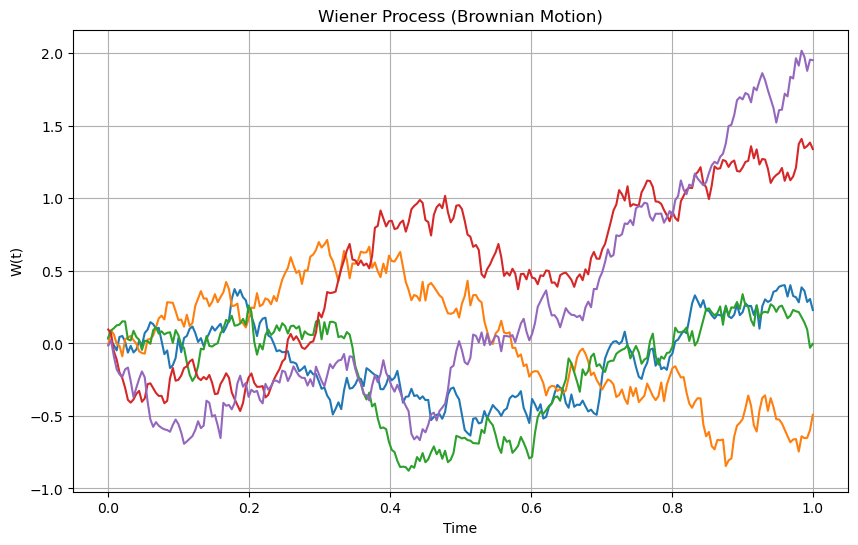

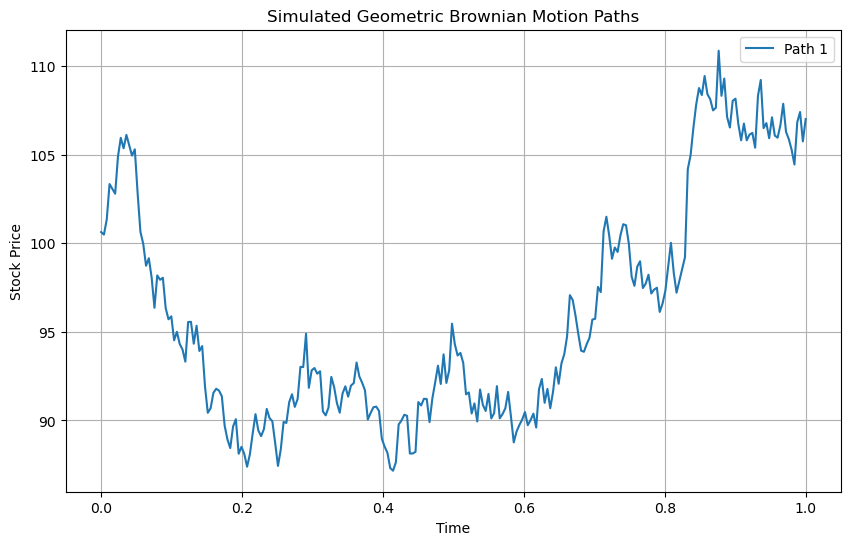

(252, 1)


In [1]:
%load_ext autoreload
%autoreload 0
import import_ipynb
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from gaussian_brownian import gbm

In [6]:
def rolling_volatility(prices, window_size, path=None, annualize=True):
    '''Calculate rolling volatility for a given price series.
    Parameters:
    prices: numpy array of price data
    window_size: int, size of the rolling window
    path: int, index of the path to analyze (for multi-path data)
    annualize: bool, whether to annualize the volatility
    Returns:
    pandas Series of rolling volatility values
    '''
    if prices.shape[1] > 1 and path is None:
        raise ValueError("Path index must be specified for multi-path data.")
    if path is not None and (path < 0 or path >= prices.shape[1]):
        raise ValueError("Path index out of bounds.")
    if path is not None:
        prices = prices[:, path]
    price_series = pd.Series(prices.flatten())
    volatility = price_series.rolling(window_size).std() * np.sqrt(252)
    if not annualize:
        volatility /= np.sqrt(252)
    return volatility

Text(0.5, 1.0, 'Rolling Volatility of GBM Path')

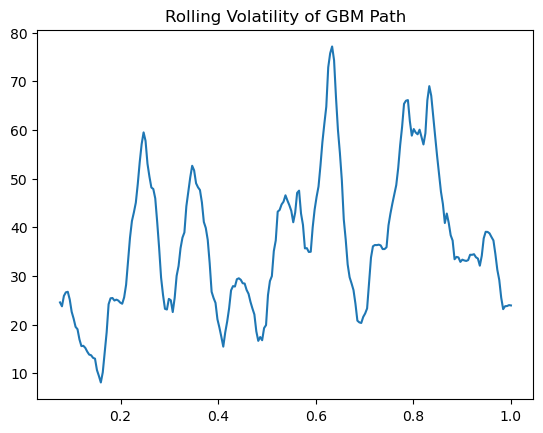

In [7]:
#Create a sample path of the geometric brownian motion to calculate the rolling volatility
gbm_paths, times = gbm(n_paths=3)
rolling_volatility_values = rolling_volatility(gbm_paths, window_size=20, path=0)
plt.plot(times, rolling_volatility_values)
plt.title("Rolling Volatility of GBM Path") 